## 挂载google网盘

In [1]:
!ls


sample_data


In [2]:
# mount on google drive
from google.colab import drive
drive.mount('/content/drive/')



Mounted at /content/drive/


In [3]:
!ls


drive  sample_data


In [4]:
import os
os.chdir('/content/drive/MyDrive/satellite-altimetry-course')


## Jason-3数据处理

In [12]:
# !pip install cartopy
# !pip install netCDF4
# !pip install pyrsimg



In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import netCDF4 as nc
import numpy as np
from pyrsimg import readTiff, imgShow


In [14]:
path_ja3 = 'data/radar/JA3_GPN_2PfP123_216_20190619_125511_20190619_135124.nc'
path_rsimg = 'data/rsimg/yangzonghai_s2_20200511_wgs84.tif'


In [15]:
## 1. jason altimetry data
ja3 = nc.Dataset(path_ja3)
## 2. remote sensing image
rsimg = readTiff(path_rsimg)


In [16]:
### 属性信息
print(ja3)


<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    Conventions: CF-1.7
    title: GDR - Standard dataset
    source: Processing Baseline F v1.01
    contact: CNES aviso@altimetry.fr, EUMETSAT ops@eumetsat.int, NOAA NODC.services@noaa.gov
    reference_document: Jason-3 Products Handbook, SALP-MU-M-OP-16118-CN
    mission_name: Jason-3
    altimeter_sensor_name: Poseidon-3B
    radiometer_sensor_name: AMR
    doris_sensor_name: DGXX-S
    gpsr_sensor_name: GPSP
    institution: CNES
    history: 2021-03-06 12:54:25 : Creation
    references: L1 library=V5.5p1, L2 library=V6.5p1p2, Processing Pilot=V5-8p1p2
    processing_center: SALP
    acq_station_name: CNES
    cycle_number: 123
    absolute_rev_number: 15986
    pass_number: 216
    absolute_pass_number: 31204
    equator_time: 2019-06-19 13:23:17.501000
    equator_longitude: 112.68
    first_meas_time: 2019-06-19 12:55:11.238477
    last_meas_time: 2019-06-19 13:51:23.246924
    xref_altimete

In [17]:
### 变量信息
list(ja3['data_20/ku'].variables.keys())


['range_ocean',
 'range_ocean_compression_qual',
 'range_ocean_mle3',
 'range_ocean_mle3_compression_qual',
 'range_adaptive',
 'range_adaptive_compression_qual',
 'swh_ocean',
 'swh_ocean_compression_qual',
 'swh_ocean_mle3',
 'swh_ocean_mle3_compression_qual',
 'swh_adaptive',
 'swh_adaptive_compression_qual',
 'sig0_ocean',
 'sig0_ocean_compression_qual',
 'sig0_ocean_mle3',
 'sig0_ocean_mle3_compression_qual',
 'sig0_adaptive',
 'sig0_adaptive_compression_qual',
 'off_nadir_angle_wf_ocean',
 'off_nadir_angle_wf_ocean_compression_qual',
 'num_iterations_ocean',
 'num_iterations_ocean_mle3',
 'num_iterations_adaptive',
 'range_ocog',
 'sig0_ocog',
 'ocog_qual',
 'mqe_ocean',
 'mqe_ocean_mle3',
 'mqe_adaptive',
 'peakiness',
 'wvf_main_class']

## 查看卫星轨迹


In [24]:
# ## 时间转换
lat_20hz_ja3, lon_20hz_ja3 = ja3['data_20/latitude'][:], ja3['data_20/longitude'][:]


Text(0.5, 1.0, 'jason-3')

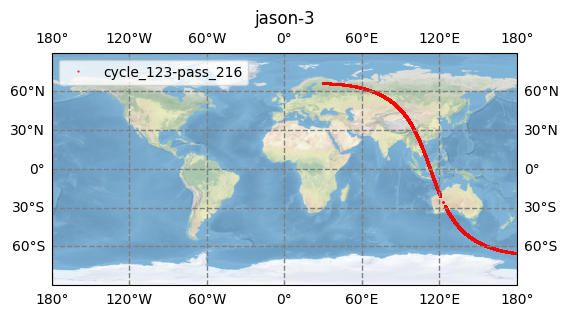

In [21]:
proj = ccrs.PlateCarree(central_longitude=0.0)
fig = plt.figure(figsize=(6, 6))
orbit_ja3 = 'cycle_'+str(ja3.cycle_number)+'-pass_'+str(ja3.pass_number)
## jason-3
ax3 = fig.add_subplot(111, projection=proj);
ax3.stock_img()
ax3.plot(lon_20hz_ja3, lat_20hz_ja3, marker='.', markersize=1,
                                linewidth=0.0, label=orbit_ja3, color='red')
ax3.gridlines(draw_labels=True, linewidth=1, color='gray', linestyle='--')
ax3.legend();
plt.title('jason-3')


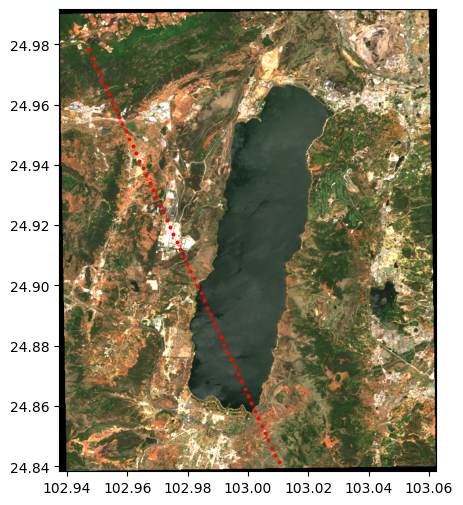

In [22]:
ids = np.where((lat_20hz_ja3>24.84) & (lat_20hz_ja3<24.98))
fig = plt.figure(figsize=(6, 6))
imgShow(rsimg.array, extent=rsimg.geoextent)
plt.scatter(x=lon_20hz_ja3[ids], y=lat_20hz_ja3[ids], s=3.5, color='red')  ## jason data
